# Example 20: Support Vector Machines

Support Vector Machine (SVM) is a powerful machine learning algorithm primarily used for classification tasks. It works by finding the optimal hyperplane that best separates different classes in the input data.

Here's how SVMs work:

- **Data Representation**: SVM starts with a labeled dataset where each data point belongs to one of two classes (binary classification). Each data point is represented as a feature vector in a multi-dimensional space.
- **Finding the Hyperplane**: SVM's main goal is to find a hyperplane (a decision boundary) that best separates the data points into two classes. This hyperplane should have the largest margin, which is the maximum distance between any data point and the hyperplane. SVM strives to find the hyperplane that maximizes this margin.
- **Support Vectors**: Data points closest to the hyperplane, known as support vectors, are crucial in determining the hyperplane's position. These support vectors are used to define the margin and the hyperplane's orientation.
- **Kernel Trick**: SVM can handle non-linearly separable data by using a kernel function. The kernel function maps the original data into a higher-dimensional space, making it possible to find a hyperplane that can separate the data even if it's not linearly separable in the original space.
- **Classification**: Once the optimal hyperplane is determined, it can be used for classification. When a new, unlabeled data point is given, SVM checks on which side of the hyperplane it falls. Based on its position relative to the hyperplane, SVM assigns the data point to one of the two classes.

It is important to note that while SVMs are very popular in academic settings, their computational complexity makes them less appealing in industry applications. 

In [1]:
# Standard imports 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset 
from sklearn import datasets

# For model and evaluation
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Here, we use the iris model, one we've used several times for classification problems. Notice that we use features $X_1$ and $X_2$ in this instance, corresponding to petal length and sepal width. 

In [2]:
# Load the iris dataset
iris = datasets.load_iris()
X = iris.data[:, 1:3]  # We'll use only the second and third features for visualization
y = iris.target

# Split the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=20)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=20)

# For fitting the function once hyperparameters are selected
X_train_val = np.concatenate((X_train, X_val))
y_train_val = np.concatenate((y_train, y_val))

The SVM kernel is a hyperparameter that we choose. Here, we assume that we will just use the linear kernel with no selection process. It is, however, a beneficial exercise to tinker with this kernel and see how it impacts the results. 

In [3]:
kernel = 'linear'

As we typically do, we model the problem with arbitrary hyperparameter values using the training set and evaluating against the validation set. This is generally good practice as it allows us to gain some intuition about the problem and define the search space for the hyperparameters, 

In [4]:
lam = 1

# Create an SVM classifier
svm_classifier = SVC(kernel=kernel, C=lam, random_state=21)

# Train the SVM classifier
svm_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_classifier.predict(X_val)

# Calculate accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.97


Here, we calculate various metrics: the confusion matrix, the classification report, and finally the classification graph. 

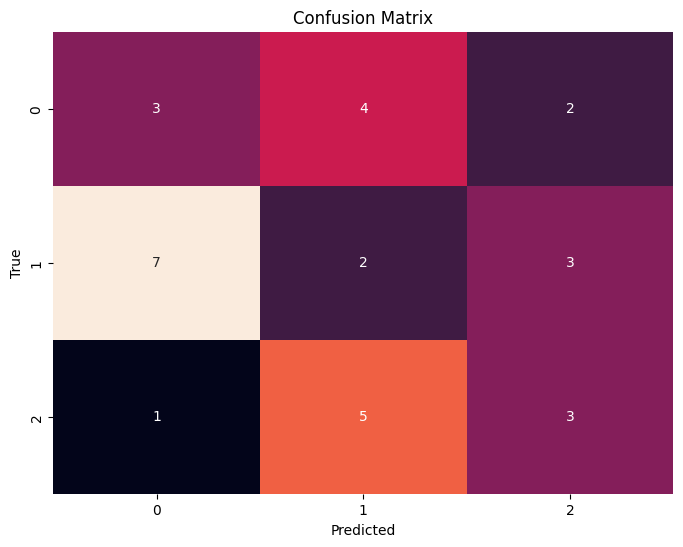

In [5]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a figure for the confusion matrix heatmap
plt.figure(figsize=(8, 6))

# Use Seaborn's heatmap to create a full-color confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cbar=False)

# Add labels and title
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

# Display the plot
plt.show()

In [6]:
report = classification_report(y_val, y_pred, target_names=iris.target_names)
print('\nClassification Report:\n', report)


Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.89      0.94         9

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



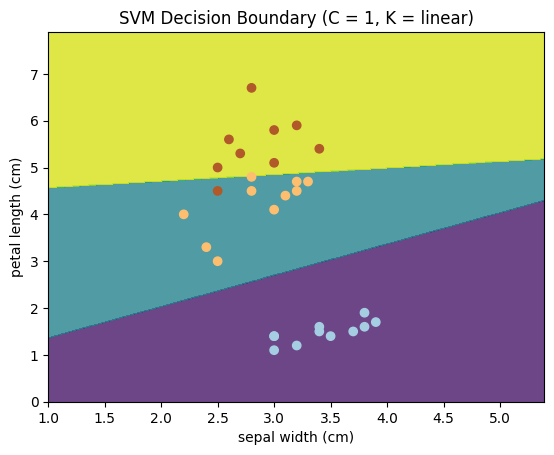

In [7]:
# Create a meshgrid for visualization
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Plot the decision boundary
Z = svm_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap=plt.cm.Paired)
plt.xlabel(iris.feature_names[1])
plt.ylabel(iris.feature_names[2])
plt.title(f'SVM Decision Boundary (C = {lam}, K = {kernel})')
plt.show()

We now search for an optimal regularization hyperparameter based on accuracy with the validation set. 

In [8]:
lam_values = np.arange(0.01, 0.55, 0.05)
accuracies = []

for lam in lam_values: 
    # Create an SVM classifier
    svm = SVC(kernel='linear', C=lam, random_state=21)

    # Train the SVM classifier
    svm.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = svm.predict(X_val)

    # Calculate accuracy
    accuracy = accuracy_score(y_val, y_pred)
    accuracies.append(accuracy)

best_lambda = round(lam_values[np.argmax(accuracies)], 2) # Rounding avoids floating point error
print(f"Best lambda based on validation accuracy: {best_lambda}")

Best lambda based on validation accuracy: 0.06


Here, we plot the validation accuracies against the regularization parameters to see if there are any unanticipated behaviors that would warrant searching outside the space. 

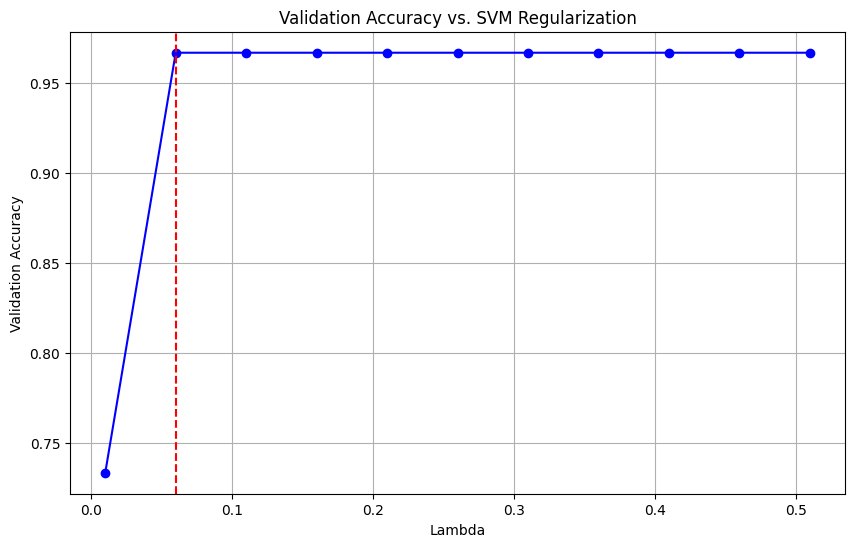

In [9]:
# Plot lambda values vs. validation set metrics
plt.figure(figsize=(10, 6))
plt.plot(lam_values, accuracies, marker='o', linestyle='-', color='blue')
plt.axvline(x=best_lambda, color='r', linestyle='--', label='Best Lambda')
plt.title('Validation Accuracy vs. SVM Regularization')
plt.xlabel('Lambda')
plt.ylabel('Validation Accuracy')
plt.grid(True)

Now that we have selected the regularization parameter, let's define the final model and provide metrics. 

In [10]:
# Create an SVM classifier
svm_classifier = SVC(kernel=kernel, C=best_lambda, random_state=21)

# Train the SVM classifier
svm_classifier.fit(X_train_val, y_train_val)

# Make predictions on the test set
y_pred = svm_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.97


In [11]:
report = classification_report(y_test, y_pred, target_names=iris.target_names)
print('\nClassification Report:\n', report)


Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         9
  versicolor       1.00      0.92      0.96        12
   virginica       0.90      1.00      0.95         9

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



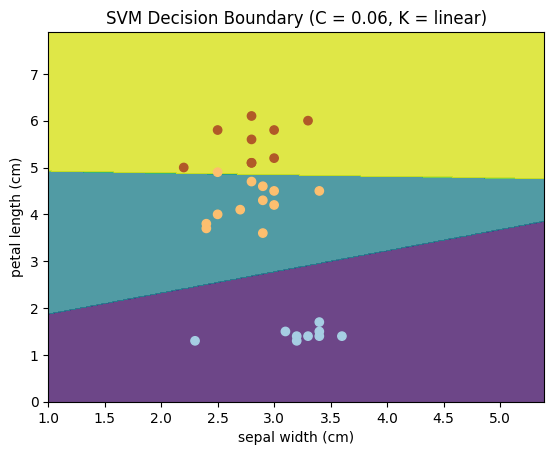

In [12]:
# Create a meshgrid for visualization
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Plot the decision boundary
Z = svm_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.Paired)
plt.xlabel(iris.feature_names[1])
plt.ylabel(iris.feature_names[2])
plt.title(f'SVM Decision Boundary (C = {best_lambda}, K = {kernel})')
plt.show()